In [9]:
import bagpy
from bagpy import bagreader
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d
import plotly.graph_objects as go
import nbformat
import numpy as np


[INFO]  Data folder ./hibachi_log_2022-06-10-10-58-55 already exists. Not creating.
Index(['Time', 'header.seq', 'header.stamp.secs', 'header.stamp.nsecs',
       'header.frame_id', 'vector.x', 'vector.y', 'vector.z'],
      dtype='str')


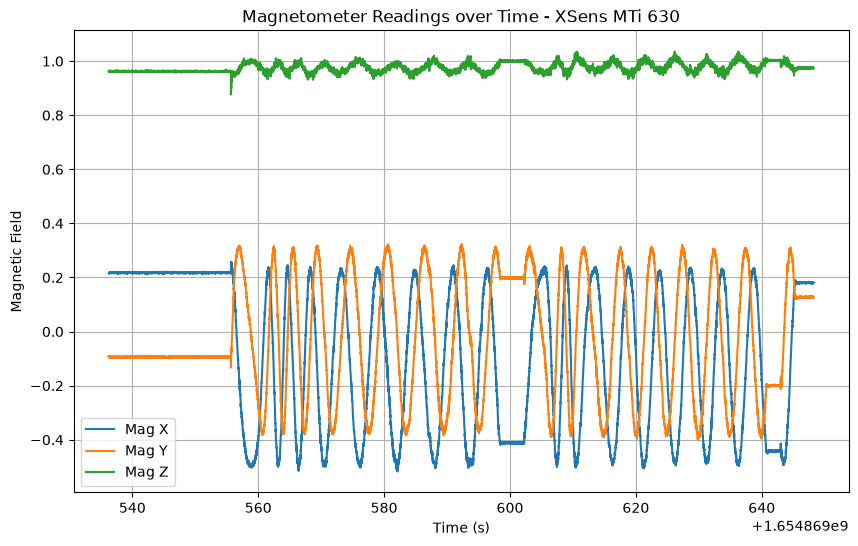

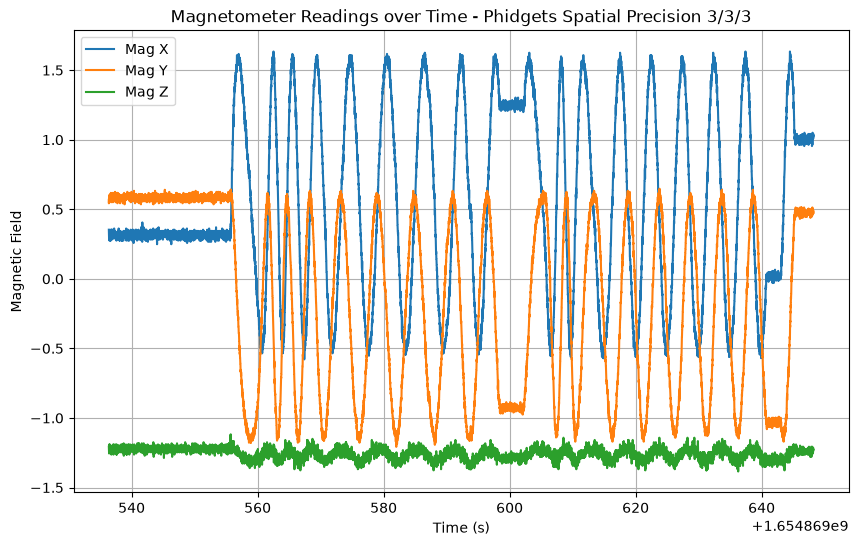

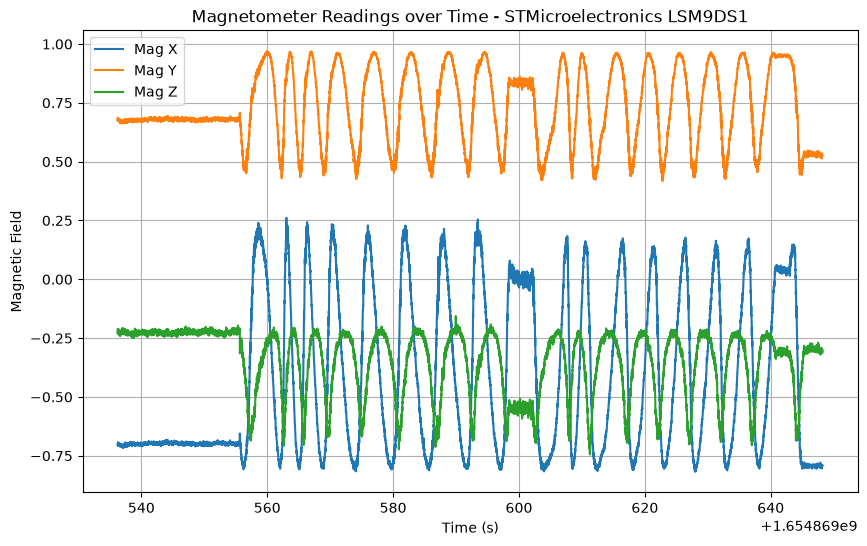

In [10]:
def plot_mag_data(_mag_data, imu_model=None, show=False):

    plot_title = "Magnetometer Readings over Time"
    if imu_model is not None:
        plot_title += " - " + imu_model

    plt.figure(figsize=(10, 6))
    try:        
        plt.plot(_mag_data['Time'], _mag_data['vector.x'], label='Mag X')
        plt.plot(_mag_data['Time'], _mag_data['vector.y'], label='Mag Y')
        plt.plot(_mag_data['Time'], _mag_data['vector.z'], label='Mag Z')
    except KeyError:
        plt.plot(_mag_data['Time'], _mag_data['magnetic_field.x'], label='Mag X')
        plt.plot(_mag_data['Time'], _mag_data['magnetic_field.y'], label='Mag Y')
        plt.plot(_mag_data['Time'], _mag_data['magnetic_field.z'], label='Mag Z')
    plt.xlabel('Time (s)')
    plt.ylabel('Magnetic Field')

    plt.title(plot_title)
    plt.legend()
    plt.grid(True)
    if show:
        plt.show()


# 1. Read the bag file
b = bagreader('./hibachi_log_2022-06-10-10-58-55.bag')

# 2. Get the specific topic's data (saves as a CSV automatically)
# To find your topic names, you can first run: print(b.topic_table)
# print(b.topic_table)

# The magnetometer topics are the following
# /mti_630_8A1G6/imu/mag ---> XSens MTi 630
# /phidgets_373223/imu/mag ---> Phidgets Spatial Precision 3/3/3
# /hibachi_imu_node/mag ---> STMicroelectronics LSM9DS1

mti_630_mag = b.message_by_topic(topic='/mti_630_8A1G6/imu/mag')
phidgets_mag = b.message_by_topic(topic='/phidgets_373223/imu/mag')
lsm9ds1_mag = b.message_by_topic(topic='/hibachi_imu_node/mag')


# 3.1. Load the data into a pandas DataFrame
df0 = pd.read_csv(mti_630_mag)
print(df0.columns)

# 3.2. Plot the data
plot_mag_data(df0, imu_model="XSens MTi 630", show=False)

# 4.1. Load the data into a pandas DataFrame
df1 = pd.read_csv(phidgets_mag)
# Pasar a [G]
df1['magnetic_field.x'] /= 1e-4
df1['magnetic_field.y'] /= 1e-4
df1['magnetic_field.z'] /= 1e-4

# 4.2. Plot the data
plot_mag_data(df1, imu_model="Phidgets Spatial Precision 3/3/3", show=False)

# 5.1. Load the data into a pandas DataFrame
df2 = pd.read_csv(lsm9ds1_mag)
# Pasar a [G]
df2['magnetic_field.x'] /= 1e-4
df2['magnetic_field.y'] /= 1e-4
df2['magnetic_field.z'] /= 1e-4

# 5.2. Plot the data
plot_mag_data(df2, imu_model="STMicroelectronics LSM9DS1", show=True)

# PARTE 1 — Filtro de Kalman SIN PCA (estado 3D, 9 parámetros)

El estado es el vector completo del elipsoide 3D $\theta\in\mathbb R^9$. Se estima recursivamente (RLS) muestra a muestra sobre los datos crudos $\tilde{\mathbf m}=(x,y,z)$.

> **Limitación:** para los sensores que giran casi sobre un plano (`df0`, `df1`) el elipsoide 3D es degenerado ($A$ no definida positiva). En la **Parte 2** se proyecta por PCA y se estima una elipse 2D ($\theta\in\mathbb R^5$), que resuelve esa degeneración.

# Calibración de magnetómetro con Filtro de Kalman (recursivo)

Misma parametrización que el MSE batch: el estado es el vector de parámetros del elipsoide
$\theta=[a_{11},a_{22},a_{33},a_{12},a_{13},a_{23},n_1,n_2,n_3]^T\in\mathbb R^9$.
La diferencia es que ahora se estima **muestra a muestra** (online) en vez de resolver $(H^TH)^{-1}H^Ty$ de una sola vez.

**Inicialización**

$$\hat\theta_{0|0}=\theta_0^{\text{inicial}}, \qquad P_{0|0}=p_0\,I_{9\times9}$$

**Paso 1 — Predicción (time update)** — el estado es estático, $F=I$:

$$\hat\theta_{k|k-1}=F\,\hat\theta_{k-1|k-1}=\hat\theta_{k-1|k-1}, \qquad
P_{k|k-1}=F\,P_{k-1|k-1}F^T+Q=P_{k-1|k-1}+Q$$

La estimación no cambia, pero la incertidumbre **crece** ($+Q$): así el filtro "deja la puerta abierta" a corregirse.

**Llega la medición** $(x_k,y_k,z_k)$ → se arma la fila de regresores y el target:

$$H_k=\big[x_k^2,\,y_k^2,\,z_k^2,\,2x_ky_k,\,2x_kz_k,\,2y_kz_k,\,x_k,\,y_k,\,z_k\big]\in\mathbb R^{1\times9},\qquad y_k=1$$

**Paso 2 — Innovación**

$$e_k=y_k-H_k\,\hat\theta_{k|k-1}, \qquad S_k=H_k\,P_{k|k-1}\,H_k^T+R \ \ (\text{escalar})$$

**Paso 3 — Ganancia de Kalman**

$$K_k=P_{k|k-1}\,H_k^T\,S_k^{-1}$$

Si $R\gg P$ → $K_k$ chico (desconfía de la medición). Si $R\ll P$ → $K_k$ grande (confía en la medición).

**Paso 4 — Corrección (measurement update)**

$$\hat\theta_{k|k}=\hat\theta_{k|k-1}+K_k\,e_k, \qquad P_{k|k}=(I-K_kH_k)\,P_{k|k-1}$$

**Recuperación de parámetros físicos** (igual que en el MSE):

$$\hat A\leftarrow\hat\theta_{1:6},\ \hat{\mathbf n}\leftarrow\hat\theta_{7:9},\quad
\hat{\mathbf b}_{HI}=-\tfrac12\hat A^{-1}\hat{\mathbf n},\quad \hat h^2=\hat{\mathbf b}_{HI}^T\hat A\hat{\mathbf b}_{HI}+1,\quad
\hat A=R\Lambda R^T\Rightarrow \hat S_I=\Lambda^{1/2}R^T$$

> **Nota:** con $Q=0$ y $F=I$ el filtro se reduce a *Recursive Least Squares* y converge exactamente a la solución batch $(H^TH)^{-1}H^Ty$. Por eso en cada sensor comparamos $\hat\theta_{KF}$ contra $\hat\theta_{\text{batch}}$.

A continuación, **por sensor**, se hacen dos análisis: **(A) del algoritmo** (convergencia de $\theta$, traza de $P$, innovación, ganancia) y **(B) de los gráficos** (calibración resultante: elipsoide crudo vs esfera calibrada).

## Sección 1 — XSens MTi 630 (`df0`)

### 1.A — Análisis del algoritmo
Se corre el KF recursivo muestra a muestra y se observa: convergencia de $\theta$, caída de la traza de $P$ (incertidumbre), evolución de la innovación $e_k$ y de la ganancia $\|K_k\|$. Se compara $\hat\theta_{KF}$ con la solución batch.

XSens MTi 630 — análisis del algoritmo
theta_KF    = [-1.5000e-03  2.9000e-03 -1.0645e+00  1.2000e-03 -7.0200e-02  1.4500e-02
  1.3700e-01 -2.7900e-02  2.0632e+00]
theta_batch = [-1.5000e-03  2.9000e-03 -1.0645e+00  1.2000e-03 -7.0200e-02  1.4500e-02
  1.3700e-01 -2.7900e-02  2.0632e+00]
||theta_KF - theta_batch|| = 1.356e-05
trace(P): 8.00e+06 (inicial) -> 6.02e+01 (final)
|innovación| media: todas=0.0002   últimas 100=0.0001


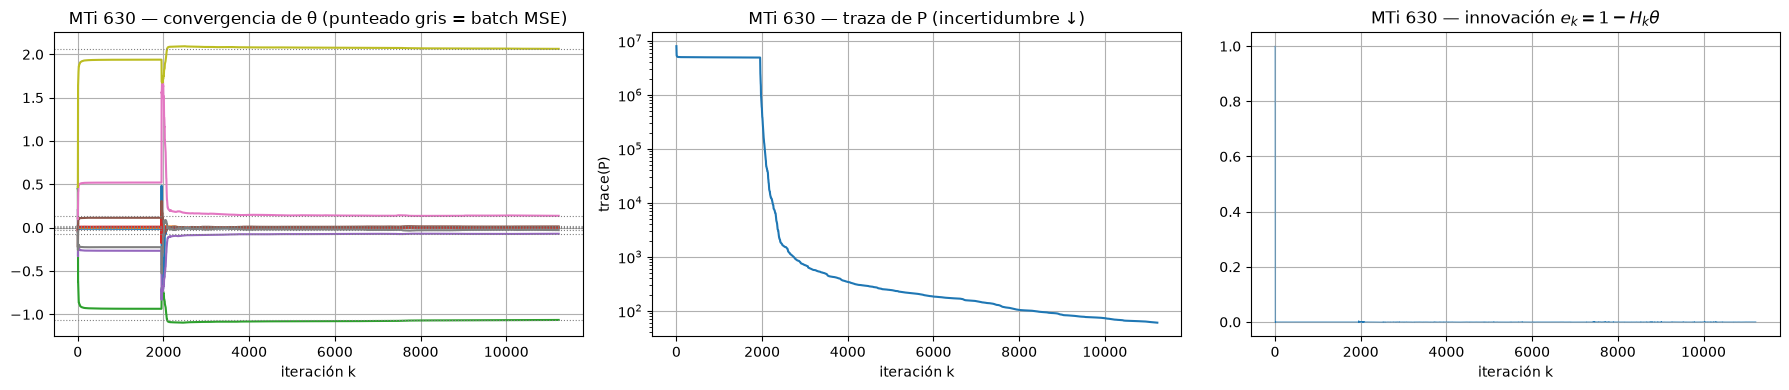

In [11]:
# ============ KF recursivo — XSens MTi 630 (df0) : ANÁLISIS DEL ALGORITMO ============
try:
    M = df0[['vector.x', 'vector.y', 'vector.z']].to_numpy()
except KeyError:
    M = df0[['magnetic_field.x', 'magnetic_field.y', 'magnetic_field.z']].to_numpy()
x, y, z = M[:, 0], M[:, 1], M[:, 2]
N = M.shape[0]

# Inicialización:  theta_0|0 = 0 ,  P_0|0 = p0 I_9
theta = np.zeros(9)
p0 = 1e6
P = p0 * np.eye(9)
Q = np.zeros((9, 9))     # estado estático -> Q = 0 (RLS). Subir Q para "dejar la puerta abierta".
R = 1.0                  # ruido de medición (escalar, y_k = 1)
I9 = np.eye(9)

theta_hist = np.zeros((N, 9))
trace_hist = np.zeros(N)
innov_hist = np.zeros(N)
gain_hist  = np.zeros(N)

for k in range(N):
    # Paso 1 - Predicción (F = I):  theta_k|k-1 = theta_k-1|k-1 ;  P_k|k-1 = P + Q
    P = P + Q

    # Medición k:  H_k (1x9), y_k = 1
    xk, yk, zk = x[k], y[k], z[k]
    Hk = np.array([[xk**2, yk**2, zk**2, 2*xk*yk, 2*xk*zk, 2*yk*zk, xk, yk, zk]])
    y_meas = 1.0

    # Paso 2 - Innovación
    e = y_meas - (Hk @ theta)[0]          # e_k = y_k - H_k theta_k|k-1
    S = (Hk @ P @ Hk.T)[0, 0] + R         # S_k = H_k P H_k^T + R

    # Paso 3 - Ganancia de Kalman
    K = (P @ Hk.T) / S                    # K_k = P H_k^T S_k^{-1}   (9x1)

    # Paso 4 - Corrección
    theta = theta + K.flatten() * e       # theta_k|k = theta_k|k-1 + K_k e_k
    P = (I9 - K @ Hk) @ P                 # P_k|k = (I - K_k H_k) P_k|k-1

    theta_hist[k] = theta
    trace_hist[k] = np.trace(P)
    innov_hist[k] = e
    gain_hist[k]  = np.linalg.norm(K)

# Solución batch MSE de referencia
H_all = np.column_stack([x**2, y**2, z**2, 2*x*y, 2*x*z, 2*y*z, x, y, z])
theta_batch = np.linalg.inv(H_all.T @ H_all) @ H_all.T @ np.ones(N)

print("XSens MTi 630 — análisis del algoritmo")
print("theta_KF    =", np.round(theta, 4))
print("theta_batch =", np.round(theta_batch, 4))
print("||theta_KF - theta_batch|| = %.3e" % np.linalg.norm(theta - theta_batch))
print("trace(P): %.2e (inicial) -> %.2e (final)" % (trace_hist[0], trace_hist[-1]))
print("|innovación| media: todas=%.4f   últimas 100=%.4f"
      % (np.abs(innov_hist).mean(), np.abs(innov_hist[-100:]).mean()))

# Gráficos del algoritmo
fig, ax = plt.subplots(1, 3, figsize=(18, 4))
ax[0].plot(theta_hist)
for j in range(9):
    ax[0].axhline(theta_batch[j], ls=':', lw=0.8, color='gray')
ax[0].set_title("MTi 630 — convergencia de θ (punteado gris = batch MSE)")
ax[0].set_xlabel("iteración k"); ax[0].grid(True)

ax[1].semilogy(trace_hist)
ax[1].set_title("MTi 630 — traza de P (incertidumbre ↓)")
ax[1].set_xlabel("iteración k"); ax[1].set_ylabel("trace(P)"); ax[1].grid(True)

ax[2].plot(innov_hist, lw=0.5)
ax[2].set_title("MTi 630 — innovación $e_k = 1 - H_k\\theta$")
ax[2].set_xlabel("iteración k"); ax[2].grid(True)
plt.tight_layout(); plt.show()

### 1.B — Análisis de los gráficos
Con el $\hat\theta$ final del KF se recuperan $\hat A,\hat{\mathbf b}_{HI},\hat h,\hat S_I$ y se grafica el dato crudo (elipsoide) vs el calibrado (esfera), y la distribución de la norma antes/después.

ADVERTENCIA: A NO es definida positiva -> [-1.06927506  0.0029253   0.00331787]
  Datos casi planares -> elipsoide 3D degenerado (ver elipse 2D en main.ipynb).
XSens MTi 630 — resultado de calibración
b_HI = [-0.1340183  -0.04089206  0.97742385]    h = 0.017214672429720884
||m_c|| (reescalado): media=1.2686  std=0.1618


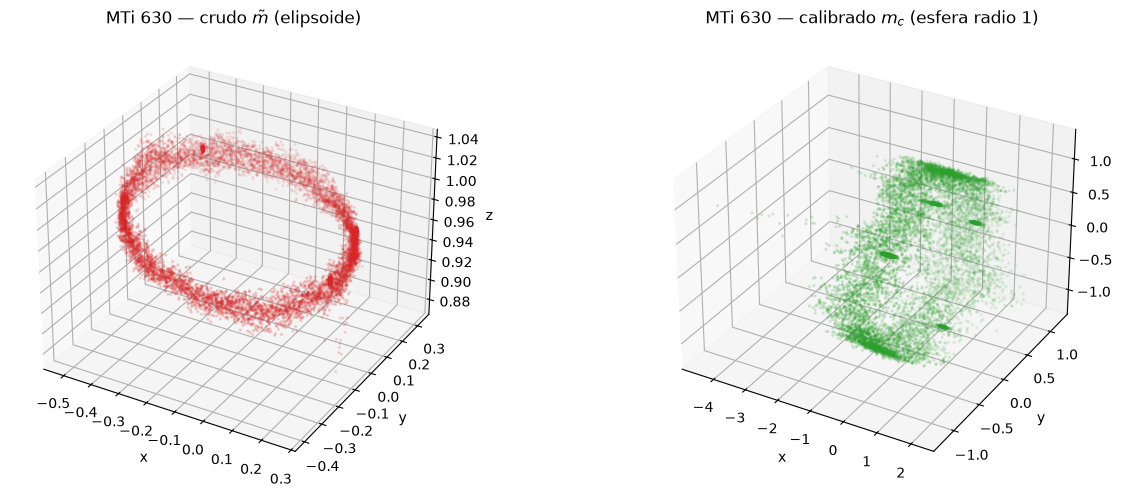

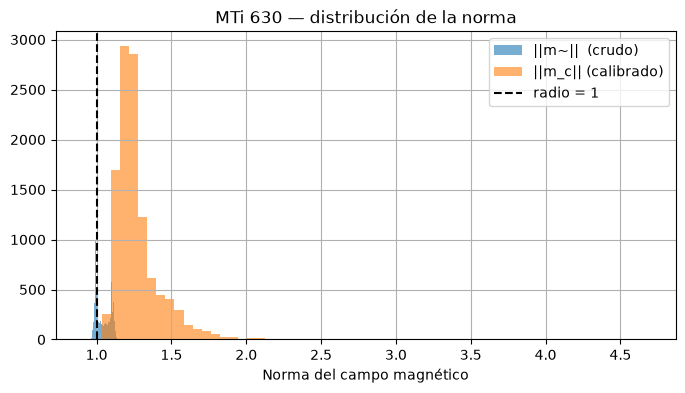

In [12]:
# ============ XSens MTi 630 : ANÁLISIS DE LOS GRÁFICOS (calibración con θ del KF) ============
a11, a22, a33, a12, a13, a23, n1, n2, n3 = theta   # theta final del KF
A = np.array([[a11, a12, a13],
              [a12, a22, a23],
              [a13, a23, a33]])
n = np.array([n1, n2, n3])

b_HI = -0.5 * np.linalg.inv(A) @ n             # Hard-Iron
h2   = b_HI @ A @ b_HI + 1.0
h    = np.sqrt(abs(h2))

eigval, Rmat = np.linalg.eigh(A)               # A = R Λ R^T  (real, simétrica)
if np.any(eigval <= 0):
    print("ADVERTENCIA: A NO es definida positiva ->", eigval)
    print("  Datos casi planares -> elipsoide 3D degenerado (ver elipse 2D en main.ipynb).")
S_I = np.diag(np.sqrt(np.abs(eigval))) @ Rmat.T  # Soft-Iron

Mc = (S_I @ (M - b_HI).T).T
Mc = Mc / h                                     # reescala a radio 1 (la escala absoluta es arbitraria)

print("XSens MTi 630 — resultado de calibración")
print("b_HI =", b_HI, "   h =", h)
print("||m_c|| (reescalado): media=%.4f  std=%.4f" %
      (np.linalg.norm(Mc, axis=1).mean(), np.linalg.norm(Mc, axis=1).std()))

fig = plt.figure(figsize=(14, 5))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.scatter(M[:, 0], M[:, 1], M[:, 2], s=2, alpha=0.4, c='tab:red')
ax1.set_title("MTi 630 — crudo $\\tilde{m}$ (elipsoide)")
ax1.set_xlabel("x"); ax1.set_ylabel("y"); ax1.set_zlabel("z")
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.scatter(Mc[:, 0], Mc[:, 1], Mc[:, 2], s=2, alpha=0.4, c='tab:green')
ax2.set_title("MTi 630 — calibrado $m_c$ (esfera radio 1)")
ax2.set_xlabel("x"); ax2.set_ylabel("y"); ax2.set_zlabel("z")
plt.tight_layout(); plt.show()

plt.figure(figsize=(8, 4))
plt.hist(np.linalg.norm(M, axis=1),  bins=60, alpha=0.6, label="||m~||  (crudo)")
plt.hist(np.linalg.norm(Mc, axis=1), bins=60, alpha=0.6, label="||m_c|| (calibrado)")
plt.axvline(1.0, color='k', ls='--', label="radio = 1")
plt.title("MTi 630 — distribución de la norma")
plt.xlabel("Norma del campo magnético"); plt.legend(); plt.grid(True); plt.show()

## Sección 2 — Phidgets Spatial Precision 3/3/3 (`df1`)

### 2.A — Análisis del algoritmo
Mismo KF recursivo sobre los datos del Phidgets (en $[G]$): convergencia de $\theta$, traza de $P$, innovación y comparación con la solución batch.

Phidgets 3/3/3 — análisis del algoritmo
theta_KF    = [ 1.0000e-04 -1.4000e-03 -6.3490e-01 -3.0000e-04  5.9000e-03  3.2000e-02
  1.4600e-02  8.0300e-02 -1.5939e+00]
theta_batch = [ 1.0000e-04 -1.4000e-03 -6.3500e-01 -3.0000e-04  5.9000e-03  3.2000e-02
  1.4600e-02  8.0300e-02 -1.5939e+00]
||theta_KF - theta_batch|| = 3.576e-07
trace(P): 8.00e+06 (inicial) -> 7.77e-01 (final)
|innovación| media: todas=0.0004   últimas 100=0.0003


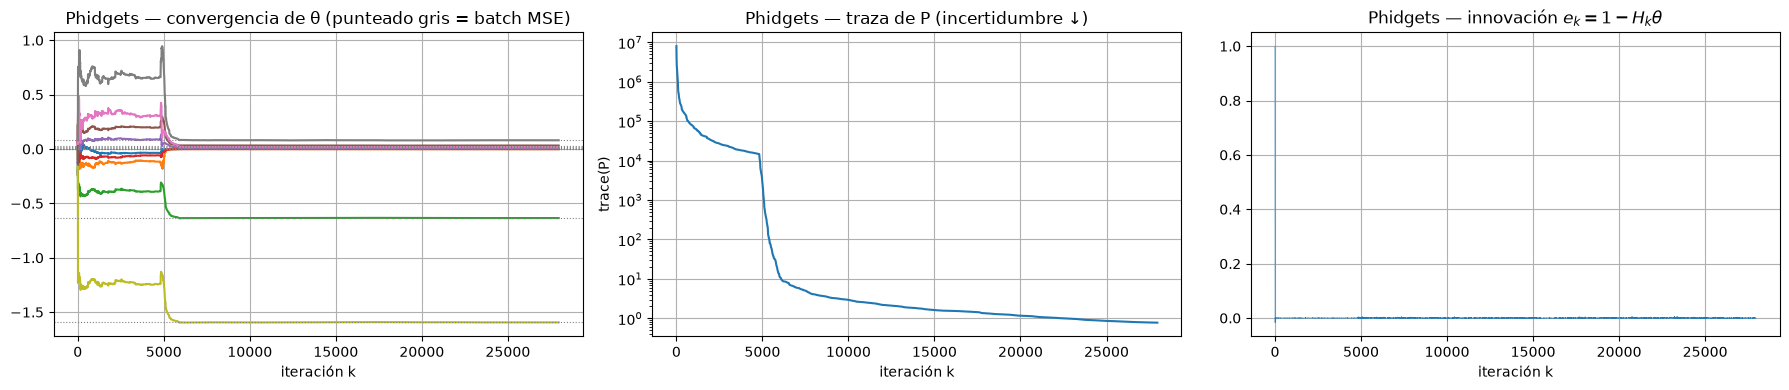

In [13]:
# ======= KF recursivo — Phidgets 3/3/3 (df1) : ANÁLISIS DEL ALGORITMO =======
try:
    M = df1[['vector.x', 'vector.y', 'vector.z']].to_numpy()
except KeyError:
    M = df1[['magnetic_field.x', 'magnetic_field.y', 'magnetic_field.z']].to_numpy()
x, y, z = M[:, 0], M[:, 1], M[:, 2]
N = M.shape[0]

# Inicialización:  theta_0|0 = 0 ,  P_0|0 = p0 I_9
theta = np.zeros(9)
p0 = 1e6
P = p0 * np.eye(9)
Q = np.zeros((9, 9))     # estado estático -> Q = 0 (RLS). Subir Q para "dejar la puerta abierta".
R = 1.0                  # ruido de medición (escalar, y_k = 1)
I9 = np.eye(9)

theta_hist = np.zeros((N, 9))
trace_hist = np.zeros(N)
innov_hist = np.zeros(N)
gain_hist  = np.zeros(N)

for k in range(N):
    # Paso 1 - Predicción (F = I):  theta_k|k-1 = theta_k-1|k-1 ;  P_k|k-1 = P + Q
    P = P + Q

    # Medición k:  H_k (1x9), y_k = 1
    xk, yk, zk = x[k], y[k], z[k]
    Hk = np.array([[xk**2, yk**2, zk**2, 2*xk*yk, 2*xk*zk, 2*yk*zk, xk, yk, zk]])
    y_meas = 1.0

    # Paso 2 - Innovación
    e = y_meas - (Hk @ theta)[0]          # e_k = y_k - H_k theta_k|k-1
    S = (Hk @ P @ Hk.T)[0, 0] + R         # S_k = H_k P H_k^T + R

    # Paso 3 - Ganancia de Kalman
    K = (P @ Hk.T) / S                    # K_k = P H_k^T S_k^{-1}   (9x1)

    # Paso 4 - Corrección
    theta = theta + K.flatten() * e       # theta_k|k = theta_k|k-1 + K_k e_k
    P = (I9 - K @ Hk) @ P                 # P_k|k = (I - K_k H_k) P_k|k-1

    theta_hist[k] = theta
    trace_hist[k] = np.trace(P)
    innov_hist[k] = e
    gain_hist[k]  = np.linalg.norm(K)

# Solución batch MSE de referencia
H_all = np.column_stack([x**2, y**2, z**2, 2*x*y, 2*x*z, 2*y*z, x, y, z])
theta_batch = np.linalg.inv(H_all.T @ H_all) @ H_all.T @ np.ones(N)

print("Phidgets 3/3/3 — análisis del algoritmo")
print("theta_KF    =", np.round(theta, 4))
print("theta_batch =", np.round(theta_batch, 4))
print("||theta_KF - theta_batch|| = %.3e" % np.linalg.norm(theta - theta_batch))
print("trace(P): %.2e (inicial) -> %.2e (final)" % (trace_hist[0], trace_hist[-1]))
print("|innovación| media: todas=%.4f   últimas 100=%.4f"
      % (np.abs(innov_hist).mean(), np.abs(innov_hist[-100:]).mean()))

fig, ax = plt.subplots(1, 3, figsize=(18, 4))
ax[0].plot(theta_hist)
for j in range(9):
    ax[0].axhline(theta_batch[j], ls=':', lw=0.8, color='gray')
ax[0].set_title("Phidgets — convergencia de θ (punteado gris = batch MSE)")
ax[0].set_xlabel("iteración k"); ax[0].grid(True)

ax[1].semilogy(trace_hist)
ax[1].set_title("Phidgets — traza de P (incertidumbre ↓)")
ax[1].set_xlabel("iteración k"); ax[1].set_ylabel("trace(P)"); ax[1].grid(True)

ax[2].plot(innov_hist, lw=0.5)
ax[2].set_title("Phidgets — innovación $e_k = 1 - H_k\\theta$")
ax[2].set_xlabel("iteración k"); ax[2].grid(True)
plt.tight_layout(); plt.show()

### 2.B — Análisis de los gráficos
Calibración resultante (con $\hat\theta$ del KF): crudo (elipsoide) vs calibrado (esfera) y distribución de la norma.

ADVERTENCIA: A NO es definida positiva -> [-6.36612455e-01  1.54010567e-04  1.80499000e-04]
  Datos casi planares -> elipsoide 3D degenerado (ver elipse 2D en main.ipynb).
Phidgets 3/3/3 — resultado de calibración
b_HI = [ 0.61999436 -0.20729182 -1.25983618]    h = 0.015004926123399378
||m_c|| (reescalado): media=1.3787  std=0.6431


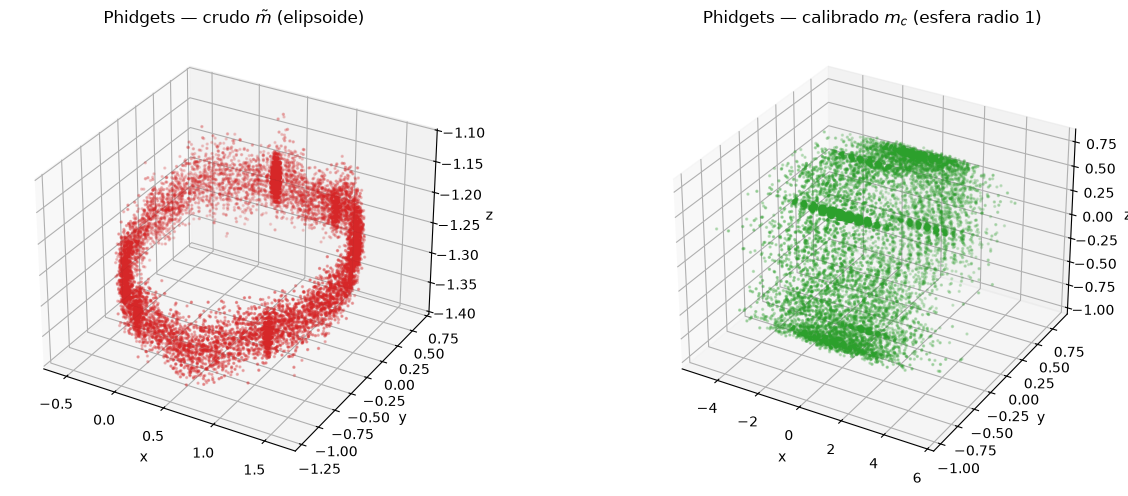

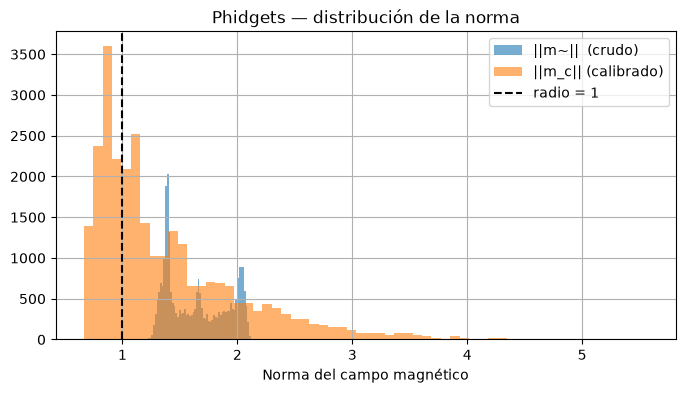

In [14]:
# ============ Phidgets 3/3/3 : ANÁLISIS DE LOS GRÁFICOS (calibración con θ del KF) ============
a11, a22, a33, a12, a13, a23, n1, n2, n3 = theta   # theta final del KF
A = np.array([[a11, a12, a13],
              [a12, a22, a23],
              [a13, a23, a33]])
n = np.array([n1, n2, n3])

b_HI = -0.5 * np.linalg.inv(A) @ n             # Hard-Iron
h2   = b_HI @ A @ b_HI + 1.0
h    = np.sqrt(abs(h2))

eigval, Rmat = np.linalg.eigh(A)               # A = R Λ R^T  (real, simétrica)
if np.any(eigval <= 0):
    print("ADVERTENCIA: A NO es definida positiva ->", eigval)
    print("  Datos casi planares -> elipsoide 3D degenerado (ver elipse 2D en main.ipynb).")
S_I = np.diag(np.sqrt(np.abs(eigval))) @ Rmat.T  # Soft-Iron

Mc = (S_I @ (M - b_HI).T).T
Mc = Mc / h                                     # reescala a radio 1 (la escala absoluta es arbitraria)

print("Phidgets 3/3/3 — resultado de calibración")
print("b_HI =", b_HI, "   h =", h)
print("||m_c|| (reescalado): media=%.4f  std=%.4f" %
      (np.linalg.norm(Mc, axis=1).mean(), np.linalg.norm(Mc, axis=1).std()))

fig = plt.figure(figsize=(14, 5))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.scatter(M[:, 0], M[:, 1], M[:, 2], s=2, alpha=0.4, c='tab:red')
ax1.set_title("Phidgets — crudo $\\tilde{m}$ (elipsoide)")
ax1.set_xlabel("x"); ax1.set_ylabel("y"); ax1.set_zlabel("z")
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.scatter(Mc[:, 0], Mc[:, 1], Mc[:, 2], s=2, alpha=0.4, c='tab:green')
ax2.set_title("Phidgets — calibrado $m_c$ (esfera radio 1)")
ax2.set_xlabel("x"); ax2.set_ylabel("y"); ax2.set_zlabel("z")
plt.tight_layout(); plt.show()

plt.figure(figsize=(8, 4))
plt.hist(np.linalg.norm(M, axis=1),  bins=60, alpha=0.6, label="||m~||  (crudo)")
plt.hist(np.linalg.norm(Mc, axis=1), bins=60, alpha=0.6, label="||m_c|| (calibrado)")
plt.axvline(1.0, color='k', ls='--', label="radio = 1")
plt.title("Phidgets — distribución de la norma")
plt.xlabel("Norma del campo magnético"); plt.legend(); plt.grid(True); plt.show()

## Sección 3 — STMicroelectronics LSM9DS1 (`df2`)

### 3.A — Análisis del algoritmo
Mismo KF recursivo sobre el LSM9DS1. **Ojo:** este sensor publica el campo ya normalizado a norma unitaria, así que $\theta$ converge a la esfera unidad ($a_{11}=a_{22}=a_{33}\approx1$, resto $\approx0$).

LSM9DS1 — análisis del algoritmo
theta_KF    = [ 9.999e-01  9.998e-01  9.998e-01  0.000e+00 -0.000e+00  1.000e-04
 -1.000e-04  2.000e-04 -1.000e-04]
theta_batch = [ 1.  1.  1. -0.  0. -0.  0. -0.  0.]
||theta_KF - theta_batch|| = 4.341e-04
trace(P): 8.00e+06 (inicial) -> 3.55e+02 (final)
|innovación| media: todas=0.0001   últimas 100=0.0000


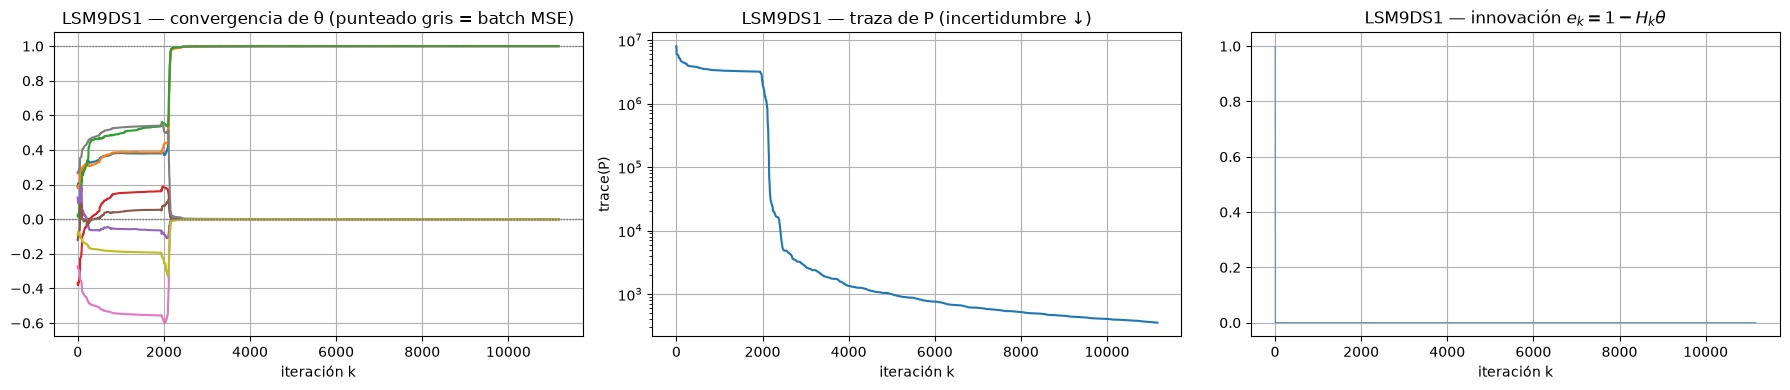

In [15]:
# ======= KF recursivo — LSM9DS1 (df2) : ANÁLISIS DEL ALGORITMO =======
try:
    M = df2[['vector.x', 'vector.y', 'vector.z']].to_numpy()
except KeyError:
    M = df2[['magnetic_field.x', 'magnetic_field.y', 'magnetic_field.z']].to_numpy()
x, y, z = M[:, 0], M[:, 1], M[:, 2]
N = M.shape[0]

# Inicialización:  theta_0|0 = 0 ,  P_0|0 = p0 I_9
theta = np.zeros(9)
p0 = 1e6
P = p0 * np.eye(9)
Q = np.zeros((9, 9))     # estado estático -> Q = 0 (RLS). Subir Q para "dejar la puerta abierta".
R = 1.0                  # ruido de medición (escalar, y_k = 1)
I9 = np.eye(9)

theta_hist = np.zeros((N, 9))
trace_hist = np.zeros(N)
innov_hist = np.zeros(N)
gain_hist  = np.zeros(N)

for k in range(N):
    # Paso 1 - Predicción (F = I):  theta_k|k-1 = theta_k-1|k-1 ;  P_k|k-1 = P + Q
    P = P + Q

    # Medición k:  H_k (1x9), y_k = 1
    xk, yk, zk = x[k], y[k], z[k]
    Hk = np.array([[xk**2, yk**2, zk**2, 2*xk*yk, 2*xk*zk, 2*yk*zk, xk, yk, zk]])
    y_meas = 1.0

    # Paso 2 - Innovación
    e = y_meas - (Hk @ theta)[0]          # e_k = y_k - H_k theta_k|k-1
    S = (Hk @ P @ Hk.T)[0, 0] + R         # S_k = H_k P H_k^T + R

    # Paso 3 - Ganancia de Kalman
    K = (P @ Hk.T) / S                    # K_k = P H_k^T S_k^{-1}   (9x1)

    # Paso 4 - Corrección
    theta = theta + K.flatten() * e       # theta_k|k = theta_k|k-1 + K_k e_k
    P = (I9 - K @ Hk) @ P                 # P_k|k = (I - K_k H_k) P_k|k-1

    theta_hist[k] = theta
    trace_hist[k] = np.trace(P)
    innov_hist[k] = e
    gain_hist[k]  = np.linalg.norm(K)

# Solución batch MSE de referencia
H_all = np.column_stack([x**2, y**2, z**2, 2*x*y, 2*x*z, 2*y*z, x, y, z])
theta_batch = np.linalg.inv(H_all.T @ H_all) @ H_all.T @ np.ones(N)

print("LSM9DS1 — análisis del algoritmo")
print("theta_KF    =", np.round(theta, 4))
print("theta_batch =", np.round(theta_batch, 4))
print("||theta_KF - theta_batch|| = %.3e" % np.linalg.norm(theta - theta_batch))
print("trace(P): %.2e (inicial) -> %.2e (final)" % (trace_hist[0], trace_hist[-1]))
print("|innovación| media: todas=%.4f   últimas 100=%.4f"
      % (np.abs(innov_hist).mean(), np.abs(innov_hist[-100:]).mean()))

fig, ax = plt.subplots(1, 3, figsize=(18, 4))
ax[0].plot(theta_hist)
for j in range(9):
    ax[0].axhline(theta_batch[j], ls=':', lw=0.8, color='gray')
ax[0].set_title("LSM9DS1 — convergencia de θ (punteado gris = batch MSE)")
ax[0].set_xlabel("iteración k"); ax[0].grid(True)

ax[1].semilogy(trace_hist)
ax[1].set_title("LSM9DS1 — traza de P (incertidumbre ↓)")
ax[1].set_xlabel("iteración k"); ax[1].set_ylabel("trace(P)"); ax[1].grid(True)

ax[2].plot(innov_hist, lw=0.5)
ax[2].set_title("LSM9DS1 — innovación $e_k = 1 - H_k\\theta$")
ax[2].set_xlabel("iteración k"); ax[2].grid(True)
plt.tight_layout(); plt.show()

### 3.B — Análisis de los gráficos
Calibración resultante (con $\hat\theta$ del KF). Como los datos ya son una esfera unitaria, $\hat S_I\approx I$ y $\hat{\mathbf b}_{HI}\approx0$: la calibración es prácticamente la identidad.

LSM9DS1 — resultado de calibración
b_HI = [ 5.01957838e-05 -1.11109035e-04  7.06363394e-05]    h = 1.000000009924356
S_I  =
 [[-0.3563  0.7892 -0.4999]
 [-0.5276  0.2716  0.8048]
 [ 0.7711  0.5506  0.3197]]
||m_c|| (reescalado): media=1.0000  std=0.0000


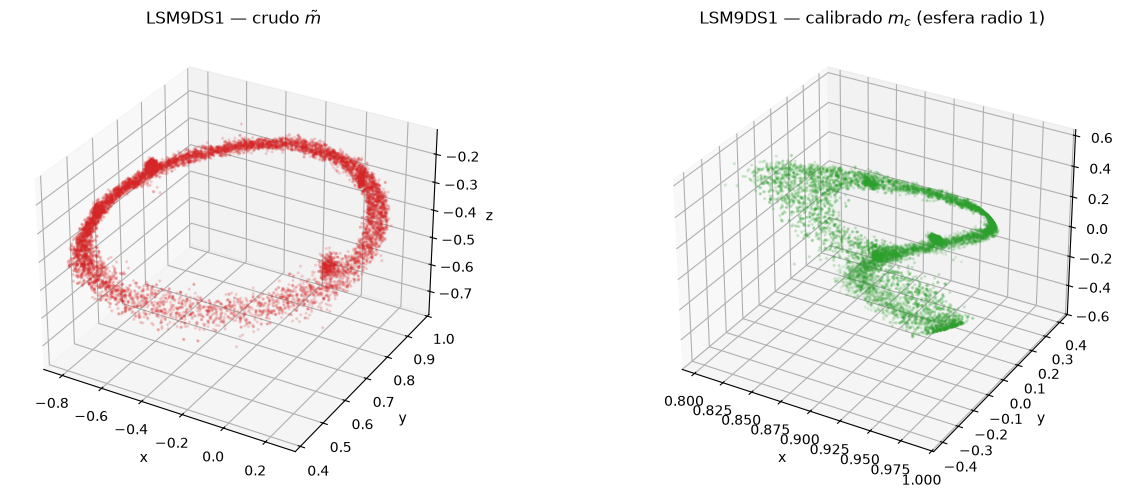

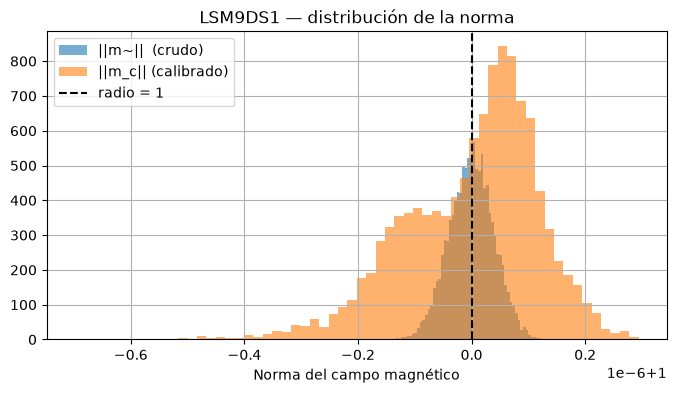

In [16]:
# ============ LSM9DS1 : ANÁLISIS DE LOS GRÁFICOS (calibración con θ del KF) ============
a11, a22, a33, a12, a13, a23, n1, n2, n3 = theta   # theta final del KF
A = np.array([[a11, a12, a13],
              [a12, a22, a23],
              [a13, a23, a33]])
n = np.array([n1, n2, n3])

b_HI = -0.5 * np.linalg.inv(A) @ n             # Hard-Iron
h2   = b_HI @ A @ b_HI + 1.0
h    = np.sqrt(abs(h2))

eigval, Rmat = np.linalg.eigh(A)               # A = R Λ R^T  (real, simétrica)
if np.any(eigval <= 0):
    print("ADVERTENCIA: A NO es definida positiva ->", eigval)
    print("  Datos casi planares -> elipsoide 3D degenerado (ver elipse 2D en main.ipynb).")
S_I = np.diag(np.sqrt(np.abs(eigval))) @ Rmat.T  # Soft-Iron

Mc = (S_I @ (M - b_HI).T).T
Mc = Mc / h                                     # reescala a radio 1 (la escala absoluta es arbitraria)

print("LSM9DS1 — resultado de calibración")
print("b_HI =", b_HI, "   h =", h)
print("S_I  =\n", np.round(S_I, 4))
print("||m_c|| (reescalado): media=%.4f  std=%.4f" %
      (np.linalg.norm(Mc, axis=1).mean(), np.linalg.norm(Mc, axis=1).std()))

fig = plt.figure(figsize=(14, 5))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.scatter(M[:, 0], M[:, 1], M[:, 2], s=2, alpha=0.4, c='tab:red')
ax1.set_title("LSM9DS1 — crudo $\\tilde{m}$")
ax1.set_xlabel("x"); ax1.set_ylabel("y"); ax1.set_zlabel("z")
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.scatter(Mc[:, 0], Mc[:, 1], Mc[:, 2], s=2, alpha=0.4, c='tab:green')
ax2.set_title("LSM9DS1 — calibrado $m_c$ (esfera radio 1)")
ax2.set_xlabel("x"); ax2.set_ylabel("y"); ax2.set_zlabel("z")
plt.tight_layout(); plt.show()

plt.figure(figsize=(8, 4))
plt.hist(np.linalg.norm(M, axis=1),  bins=60, alpha=0.6, label="||m~||  (crudo)")
plt.hist(np.linalg.norm(Mc, axis=1), bins=60, alpha=0.6, label="||m_c|| (calibrado)")
plt.axvline(1.0, color='k', ls='--', label="radio = 1")
plt.title("LSM9DS1 — distribución de la norma")
plt.xlabel("Norma del campo magnético"); plt.legend(); plt.grid(True); plt.show()

# PARTE 2 — Filtro de Kalman CON PCA (estado 2D, 5 parámetros)

Ahora se proyecta cada nube a su **mejor plano** por PCA (SVD, 2 componentes principales) y el KF estima una **elipse 2D**. El estado pasa de 9 a 5 parámetros:

$$\theta=[a_{11},a_{22},a_{12},n_1,n_2]^T\in\mathbb R^5,\qquad
H_k=[x_k^2,\,y_k^2,\,2x_ky_k,\,x_k,\,y_k]\in\mathbb R^{1\times5},\qquad y_k=1$$

El bucle recursivo (predicción → innovación → ganancia → corrección) es **idéntico** al de la Parte 1, solo cambia la dimensión del estado y la fila de regresores. Con $Q=0$, $F=I$ converge al batch 2D $(H^TH)^{-1}H^T\mathbf 1$.

**Ventaja:** al trabajar en el plano, $M_2$ queda definida positiva incluso para `df0`/`df1`, así que la elipse calibrada es propia (a diferencia del elipsoide 3D degenerado de la Parte 1).

Misma estructura por sensor: **A — análisis del algoritmo** (convergencia de $\theta$, traza de $P$, innovación) y **B — análisis de los gráficos** (mediciones proyectadas + elipse ajustada + reconstrucción 3D, círculo calibrado y norma).

## Sección 1 (PCA) — XSens MTi 630 (`df0`)

### 1.A — Análisis del algoritmo
KF recursivo sobre los datos proyectados al plano (PCA). Se observa la convergencia de $\theta\in\mathbb R^5$, la caída de la traza de $P$ y la innovación $e_k$, y se compara con la solución batch 2D.

XSens MTi 630 (PCA 2D) — análisis del algoritmo
theta_KF    = [ 7.8487  8.7362  0.1788 -0.8505 -0.3728]
theta_batch = [ 7.8487  8.7362  0.1788 -0.8505 -0.3728]
||theta_KF - theta_batch|| = 1.933e-07
trace(P): 4.00e+06 (inicial) -> 5.53e-02 (final)
|innovación| media: todas=0.0299   últimas 100=0.0190


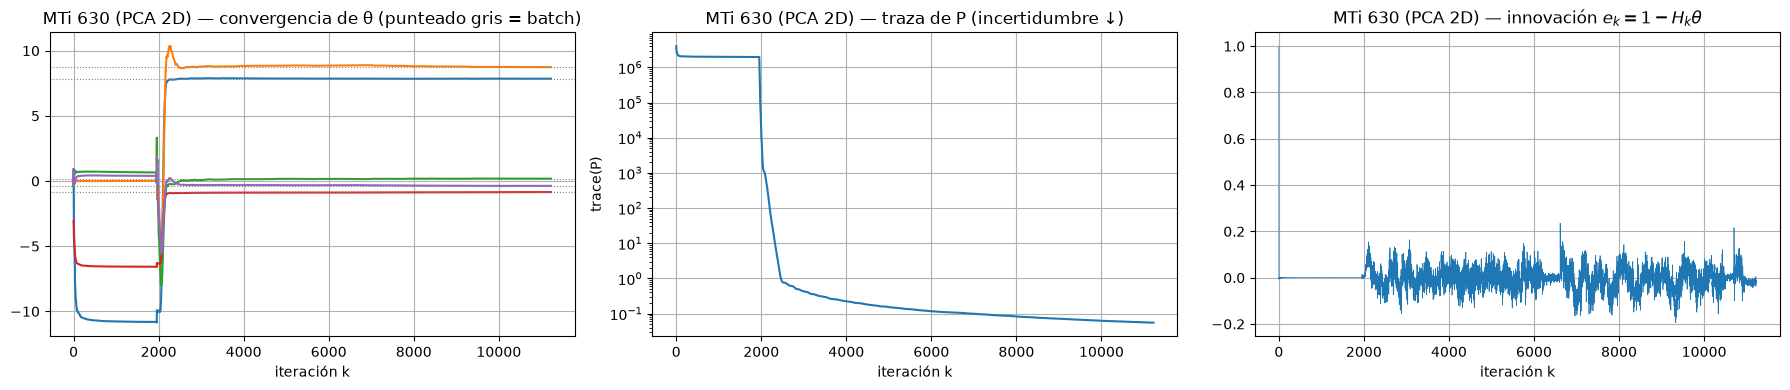

In [17]:
# ====== KF-2D con PCA — XSens MTi 630 (df0) : ANÁLISIS DEL ALGORITMO ======
try:
    M3 = df0[['vector.x', 'vector.y', 'vector.z']].to_numpy()
except KeyError:
    M3 = df0[['magnetic_field.x', 'magnetic_field.y', 'magnetic_field.z']].to_numpy()

# --- PCA por SVD: proyección al mejor plano (2 componentes principales) ---
center3 = M3.mean(axis=0)
Xc = M3 - center3
U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
P2 = Xc @ Vt[:2].T                  # coordenadas en el plano (plane.x, plane.y)
x, y = P2[:, 0], P2[:, 1]
N = P2.shape[0]

# Inicialización:  theta_0|0 = 0 (R^5) ,  P_0|0 = p0 I_5
theta = np.zeros(5)
p0 = 1e6
P = p0 * np.eye(5)
Q = np.zeros((5, 5))     # estado estático -> Q = 0 (RLS)
R = 1.0                  # ruido de medición (escalar, y_k = 1)
I5 = np.eye(5)

theta_hist = np.zeros((N, 5))
trace_hist = np.zeros(N)
innov_hist = np.zeros(N)
gain_hist  = np.zeros(N)

for k in range(N):
    # Paso 1 - Predicción (F = I):  theta_k|k-1 = theta_k-1|k-1 ;  P_k|k-1 = P + Q
    P = P + Q

    # Medición k:  H_k (1x5), y_k = 1
    xk, yk = x[k], y[k]
    Hk = np.array([[xk**2, yk**2, 2*xk*yk, xk, yk]])
    y_meas = 1.0

    # Paso 2 - Innovación
    e = y_meas - (Hk @ theta)[0]          # e_k = y_k - H_k theta_k|k-1
    S_k = (Hk @ P @ Hk.T)[0, 0] + R       # S_k = H_k P H_k^T + R

    # Paso 3 - Ganancia de Kalman
    K = (P @ Hk.T) / S_k                  # K_k = P H_k^T S_k^{-1}   (5x1)

    # Paso 4 - Corrección
    theta = theta + K.flatten() * e       # theta_k|k = theta_k|k-1 + K_k e_k
    P = (I5 - K @ Hk) @ P                 # P_k|k = (I - K_k H_k) P_k|k-1

    theta_hist[k] = theta
    trace_hist[k] = np.trace(P)
    innov_hist[k] = e
    gain_hist[k]  = np.linalg.norm(K)

# Solución batch MSE 2D de referencia
H_all = np.column_stack([x**2, y**2, 2*x*y, x, y])
theta_batch = np.linalg.inv(H_all.T @ H_all) @ H_all.T @ np.ones(N)

print("XSens MTi 630 (PCA 2D) — análisis del algoritmo")
print("theta_KF    =", np.round(theta, 4))
print("theta_batch =", np.round(theta_batch, 4))
print("||theta_KF - theta_batch|| = %.3e" % np.linalg.norm(theta - theta_batch))
print("trace(P): %.2e (inicial) -> %.2e (final)" % (trace_hist[0], trace_hist[-1]))
print("|innovación| media: todas=%.4f   últimas 100=%.4f"
      % (np.abs(innov_hist).mean(), np.abs(innov_hist[-100:]).mean()))

# Gráficos del algoritmo
fig, ax = plt.subplots(1, 3, figsize=(18, 4))
ax[0].plot(theta_hist)
for j in range(5):
    ax[0].axhline(theta_batch[j], ls=':', lw=0.8, color='gray')
ax[0].set_title("MTi 630 (PCA 2D) — convergencia de θ (punteado gris = batch)")
ax[0].set_xlabel("iteración k"); ax[0].grid(True)

ax[1].semilogy(trace_hist)
ax[1].set_title("MTi 630 (PCA 2D) — traza de P (incertidumbre ↓)")
ax[1].set_xlabel("iteración k"); ax[1].set_ylabel("trace(P)"); ax[1].grid(True)

ax[2].plot(innov_hist, lw=0.5)
ax[2].set_title("MTi 630 (PCA 2D) — innovación $e_k = 1 - H_k\\theta$")
ax[2].set_xlabel("iteración k"); ax[2].grid(True)
plt.tight_layout(); plt.show()

### 1.B — Análisis de los gráficos
Con el $\hat\theta$ final del KF se recuperan $M_2,\mathbf b,h,\hat S_I$ y se grafica: mediciones proyectadas + elipse ajustada (y su reconstrucción en 3D), nube calibrada (círculo radio 1) y distribución de la norma.

XSens MTi 630 (PCA 2D) — resultado de calibración
centro (hard-iron 2D) = [0.05371841 0.02023584]    h = 1.013220125121173
||Pc||: media=0.9989  std=0.0207


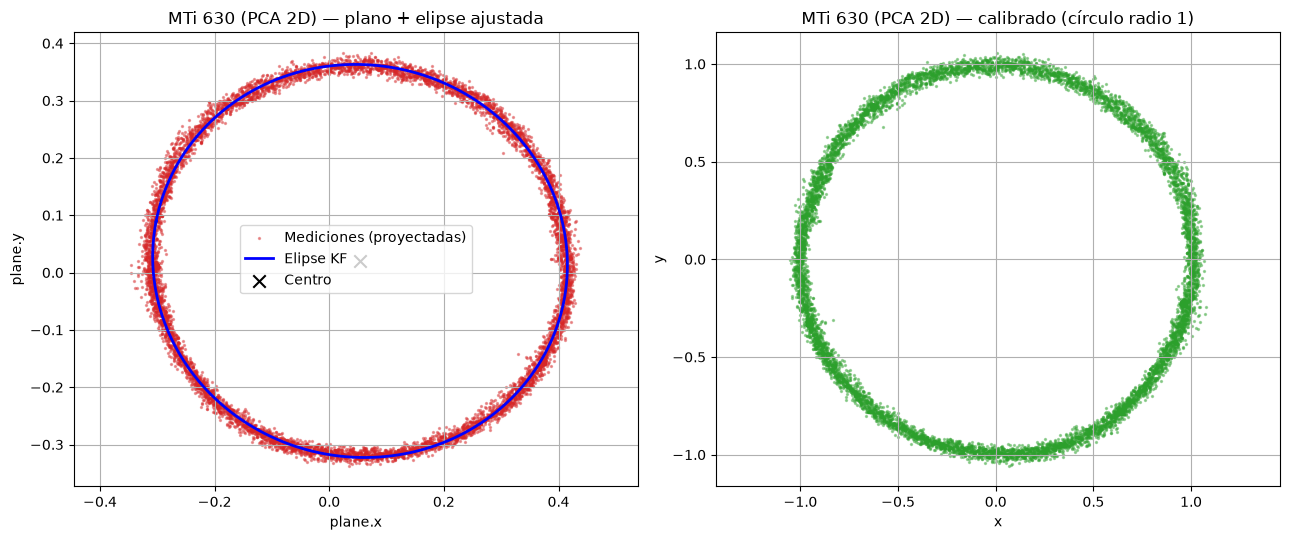

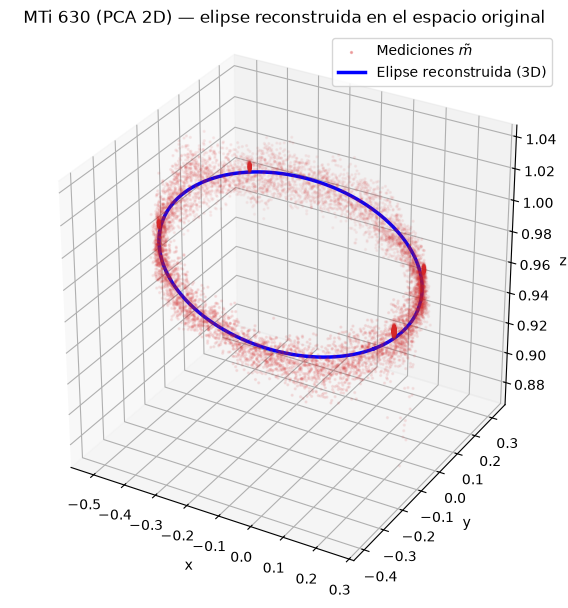

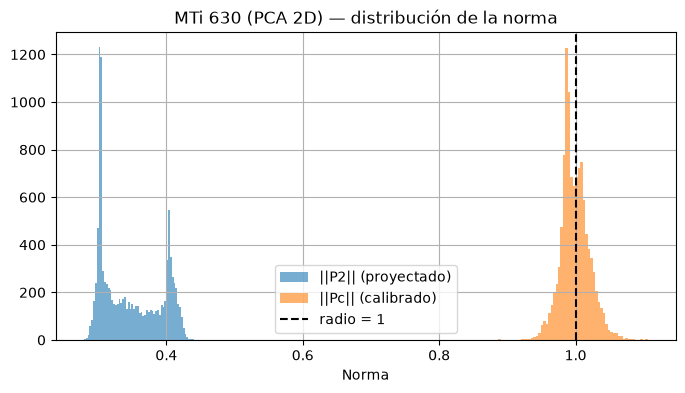

In [18]:
# ====== XSens MTi 630 (PCA 2D) : ANÁLISIS DE LOS GRÁFICOS (calibración con θ del KF) ======
a11, a22, a12, n1, n2 = theta                  # theta final del KF (2D)
M2 = np.array([[a11, a12],
               [a12, a22]])
nvec = np.array([n1, n2])
b2 = -0.5 * np.linalg.inv(M2) @ nvec           # centro (hard-iron 2D)
h  = np.sqrt(abs(b2 @ M2 @ b2 + 1.0))          # radio
eigval, Rmat = np.linalg.eigh(M2)              # M2 = R Λ R^T
if np.any(eigval <= 0):
    print("ADVERTENCIA: M2 NO es definida positiva ->", eigval)
S2 = np.diag(np.sqrt(np.abs(eigval))) @ Rmat.T  # Soft-Iron 2D
Pc = (S2 @ (P2 - b2).T).T / h                   # calibrado, radio 1

# Contorno de la elipse ajustada (plano) y su reconstrucción al espacio 3D
t = np.linspace(0, 2*np.pi, 400)
ell2d = b2.reshape(2, 1) + Rmat @ np.diag(h/np.sqrt(np.abs(eigval))) @ np.vstack([np.cos(t), np.sin(t)])
ell3d = center3 + ell2d.T @ Vt[:2]             # (400, 3)

print("XSens MTi 630 (PCA 2D) — resultado de calibración")
print("centro (hard-iron 2D) =", b2, "   h =", h)
print("||Pc||: media=%.4f  std=%.4f" %
      (np.linalg.norm(Pc, axis=1).mean(), np.linalg.norm(Pc, axis=1).std()))

# (a) plano + elipse ajustada,  (b) calibrado (círculo radio 1)
fig, ax = plt.subplots(1, 2, figsize=(13, 5.5))
ax[0].scatter(x, y, s=2, alpha=0.4, c='tab:red', label='Mediciones (proyectadas)')
ax[0].plot(ell2d[0], ell2d[1], 'b', lw=2, label='Elipse KF')
ax[0].scatter(b2[0], b2[1], c='k', marker='x', s=80, label='Centro')
ax[0].set_title("MTi 630 (PCA 2D) — plano + elipse ajustada")
ax[0].set_xlabel("plane.x"); ax[0].set_ylabel("plane.y")
ax[0].axis('equal'); ax[0].grid(True); ax[0].legend()
ax[1].scatter(Pc[:, 0], Pc[:, 1], s=2, alpha=0.4, c='tab:green')
ax[1].set_title("MTi 630 (PCA 2D) — calibrado (círculo radio 1)")
ax[1].set_xlabel("x"); ax[1].set_ylabel("y")
ax[1].axis('equal'); ax[1].grid(True)
plt.tight_layout(); plt.show()

# (c) mediciones crudas 3D + elipse reconstruida en el espacio original
fig = plt.figure(figsize=(8, 6))
ax3 = fig.add_subplot(1, 1, 1, projection='3d')
ax3.scatter(M3[:, 0], M3[:, 1], M3[:, 2], s=2, alpha=0.3, c='tab:red', label='Mediciones $\\tilde{m}$')
ax3.plot(ell3d[:, 0], ell3d[:, 1], ell3d[:, 2], 'b', lw=2.5, label='Elipse reconstruida (3D)')
ax3.set_title("MTi 630 (PCA 2D) — elipse reconstruida en el espacio original")
ax3.set_xlabel("x"); ax3.set_ylabel("y"); ax3.set_zlabel("z")
ax3.set_box_aspect([1, 1, 1]); ax3.legend()
plt.tight_layout(); plt.show()

# (d) distribución de la norma
plt.figure(figsize=(8, 4))
plt.hist(np.linalg.norm(P2, axis=1), bins=60, alpha=0.6, label="||P2|| (proyectado)")
plt.hist(np.linalg.norm(Pc, axis=1), bins=60, alpha=0.6, label="||Pc|| (calibrado)")
plt.axvline(1.0, color='k', ls='--', label="radio = 1")
plt.title("MTi 630 (PCA 2D) — distribución de la norma")
plt.xlabel("Norma"); plt.legend(); plt.grid(True); plt.show()

## Sección 2 (PCA) — Phidgets Spatial Precision 3/3/3 (`df1`)

### 2.A — Análisis del algoritmo
Mismo KF recursivo 2D sobre los datos del Phidgets proyectados al plano. Convergencia de $\theta$, traza de $P$, innovación y comparación con el batch 2D.

Phidgets 3/3/3 (PCA 2D) — análisis del algoritmo
theta_KF    = [ 1.0754  1.203  -0.2104 -0.2004  0.3058]
theta_batch = [ 1.0754  1.203  -0.2104 -0.2004  0.3058]
||theta_KF - theta_batch|| = 1.986e-10
trace(P): 4.00e+06 (inicial) -> 5.53e-04 (final)
|innovación| media: todas=0.0348   últimas 100=0.0311


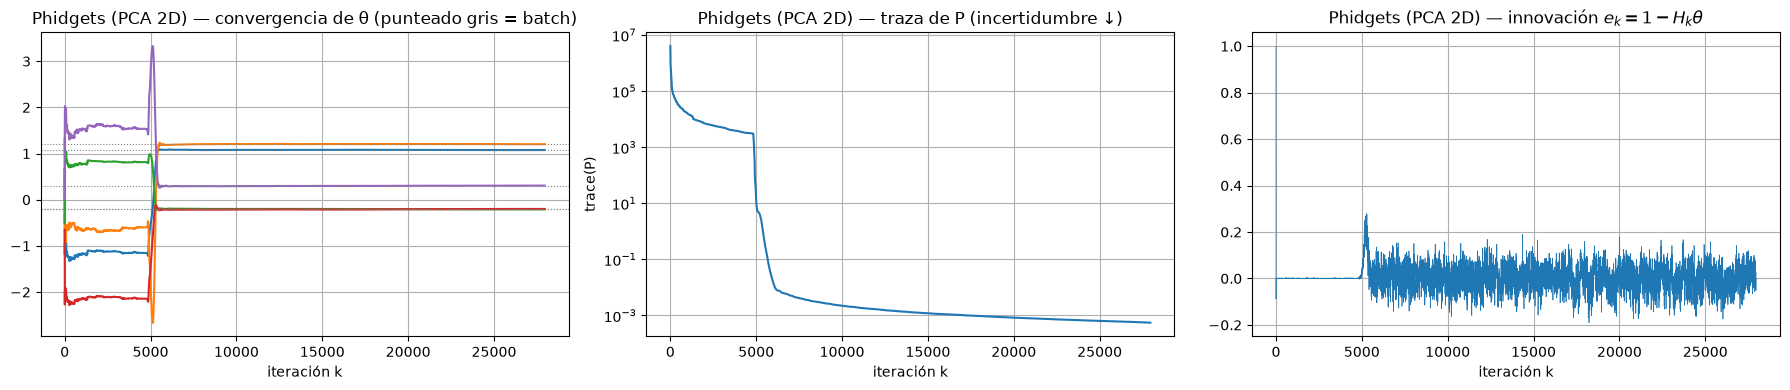

In [19]:
# ====== KF-2D con PCA — Phidgets 3/3/3 (df1) : ANÁLISIS DEL ALGORITMO ======
try:
    M3 = df1[['vector.x', 'vector.y', 'vector.z']].to_numpy()
except KeyError:
    M3 = df1[['magnetic_field.x', 'magnetic_field.y', 'magnetic_field.z']].to_numpy()

# --- PCA por SVD: proyección al mejor plano (2 componentes principales) ---
center3 = M3.mean(axis=0)
Xc = M3 - center3
U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
P2 = Xc @ Vt[:2].T                  # coordenadas en el plano (plane.x, plane.y)
x, y = P2[:, 0], P2[:, 1]
N = P2.shape[0]

# Inicialización:  theta_0|0 = 0 (R^5) ,  P_0|0 = p0 I_5
theta = np.zeros(5)
p0 = 1e6
P = p0 * np.eye(5)
Q = np.zeros((5, 5))     # estado estático -> Q = 0 (RLS)
R = 1.0                  # ruido de medición (escalar, y_k = 1)
I5 = np.eye(5)

theta_hist = np.zeros((N, 5))
trace_hist = np.zeros(N)
innov_hist = np.zeros(N)
gain_hist  = np.zeros(N)

for k in range(N):
    # Paso 1 - Predicción (F = I):  theta_k|k-1 = theta_k-1|k-1 ;  P_k|k-1 = P + Q
    P = P + Q

    # Medición k:  H_k (1x5), y_k = 1
    xk, yk = x[k], y[k]
    Hk = np.array([[xk**2, yk**2, 2*xk*yk, xk, yk]])
    y_meas = 1.0

    # Paso 2 - Innovación
    e = y_meas - (Hk @ theta)[0]          # e_k = y_k - H_k theta_k|k-1
    S_k = (Hk @ P @ Hk.T)[0, 0] + R       # S_k = H_k P H_k^T + R

    # Paso 3 - Ganancia de Kalman
    K = (P @ Hk.T) / S_k                  # K_k = P H_k^T S_k^{-1}   (5x1)

    # Paso 4 - Corrección
    theta = theta + K.flatten() * e       # theta_k|k = theta_k|k-1 + K_k e_k
    P = (I5 - K @ Hk) @ P                 # P_k|k = (I - K_k H_k) P_k|k-1

    theta_hist[k] = theta
    trace_hist[k] = np.trace(P)
    innov_hist[k] = e
    gain_hist[k]  = np.linalg.norm(K)

# Solución batch MSE 2D de referencia
H_all = np.column_stack([x**2, y**2, 2*x*y, x, y])
theta_batch = np.linalg.inv(H_all.T @ H_all) @ H_all.T @ np.ones(N)

print("Phidgets 3/3/3 (PCA 2D) — análisis del algoritmo")
print("theta_KF    =", np.round(theta, 4))
print("theta_batch =", np.round(theta_batch, 4))
print("||theta_KF - theta_batch|| = %.3e" % np.linalg.norm(theta - theta_batch))
print("trace(P): %.2e (inicial) -> %.2e (final)" % (trace_hist[0], trace_hist[-1]))
print("|innovación| media: todas=%.4f   últimas 100=%.4f"
      % (np.abs(innov_hist).mean(), np.abs(innov_hist[-100:]).mean()))

# Gráficos del algoritmo
fig, ax = plt.subplots(1, 3, figsize=(18, 4))
ax[0].plot(theta_hist)
for j in range(5):
    ax[0].axhline(theta_batch[j], ls=':', lw=0.8, color='gray')
ax[0].set_title("Phidgets (PCA 2D) — convergencia de θ (punteado gris = batch)")
ax[0].set_xlabel("iteración k"); ax[0].grid(True)

ax[1].semilogy(trace_hist)
ax[1].set_title("Phidgets (PCA 2D) — traza de P (incertidumbre ↓)")
ax[1].set_xlabel("iteración k"); ax[1].set_ylabel("trace(P)"); ax[1].grid(True)

ax[2].plot(innov_hist, lw=0.5)
ax[2].set_title("Phidgets (PCA 2D) — innovación $e_k = 1 - H_k\\theta$")
ax[2].set_xlabel("iteración k"); ax[2].grid(True)
plt.tight_layout(); plt.show()

### 2.B — Análisis de los gráficos
Calibración resultante (con $\hat\theta$ del KF 2D): mediciones proyectadas + elipse ajustada y su reconstrucción 3D, nube calibrada (círculo radio 1) y distribución de la norma.

Phidgets 3/3/3 (PCA 2D) — resultado de calibración
centro (hard-iron 2D) = [ 0.07070957 -0.11474355]    h = 1.012239633705475
||Pc||: media=0.9986  std=0.0238


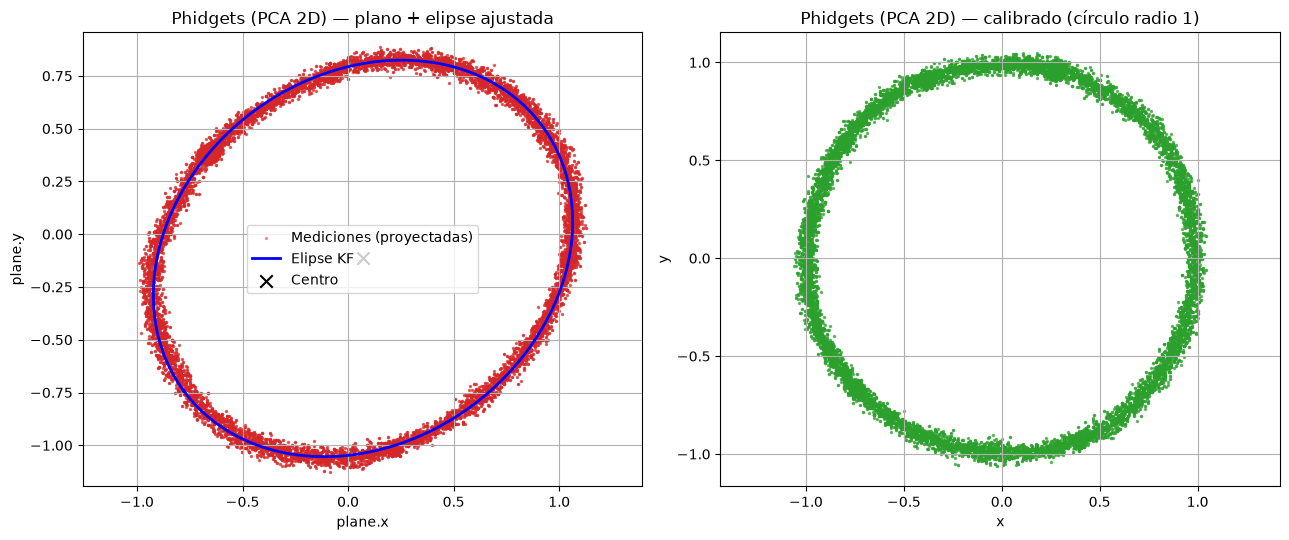

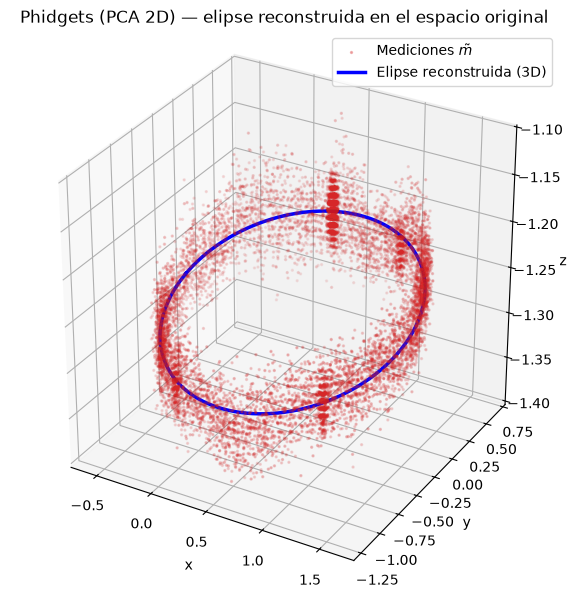

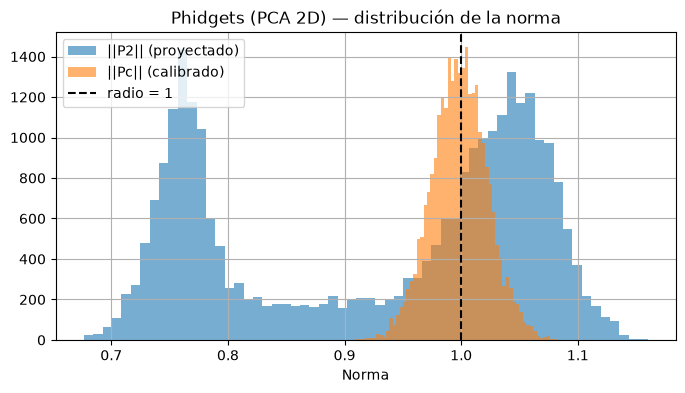

In [20]:
# ====== Phidgets 3/3/3 (PCA 2D) : ANÁLISIS DE LOS GRÁFICOS (calibración con θ del KF) ======
a11, a22, a12, n1, n2 = theta                  # theta final del KF (2D)
M2 = np.array([[a11, a12],
               [a12, a22]])
nvec = np.array([n1, n2])
b2 = -0.5 * np.linalg.inv(M2) @ nvec           # centro (hard-iron 2D)
h  = np.sqrt(abs(b2 @ M2 @ b2 + 1.0))          # radio
eigval, Rmat = np.linalg.eigh(M2)              # M2 = R Λ R^T
if np.any(eigval <= 0):
    print("ADVERTENCIA: M2 NO es definida positiva ->", eigval)
S2 = np.diag(np.sqrt(np.abs(eigval))) @ Rmat.T  # Soft-Iron 2D
Pc = (S2 @ (P2 - b2).T).T / h                   # calibrado, radio 1

# Contorno de la elipse ajustada (plano) y su reconstrucción al espacio 3D
t = np.linspace(0, 2*np.pi, 400)
ell2d = b2.reshape(2, 1) + Rmat @ np.diag(h/np.sqrt(np.abs(eigval))) @ np.vstack([np.cos(t), np.sin(t)])
ell3d = center3 + ell2d.T @ Vt[:2]             # (400, 3)

print("Phidgets 3/3/3 (PCA 2D) — resultado de calibración")
print("centro (hard-iron 2D) =", b2, "   h =", h)
print("||Pc||: media=%.4f  std=%.4f" %
      (np.linalg.norm(Pc, axis=1).mean(), np.linalg.norm(Pc, axis=1).std()))

# (a) plano + elipse ajustada,  (b) calibrado (círculo radio 1)
fig, ax = plt.subplots(1, 2, figsize=(13, 5.5))
ax[0].scatter(x, y, s=2, alpha=0.4, c='tab:red', label='Mediciones (proyectadas)')
ax[0].plot(ell2d[0], ell2d[1], 'b', lw=2, label='Elipse KF')
ax[0].scatter(b2[0], b2[1], c='k', marker='x', s=80, label='Centro')
ax[0].set_title("Phidgets (PCA 2D) — plano + elipse ajustada")
ax[0].set_xlabel("plane.x"); ax[0].set_ylabel("plane.y")
ax[0].axis('equal'); ax[0].grid(True); ax[0].legend()
ax[1].scatter(Pc[:, 0], Pc[:, 1], s=2, alpha=0.4, c='tab:green')
ax[1].set_title("Phidgets (PCA 2D) — calibrado (círculo radio 1)")
ax[1].set_xlabel("x"); ax[1].set_ylabel("y")
ax[1].axis('equal'); ax[1].grid(True)
plt.tight_layout(); plt.show()

# (c) mediciones crudas 3D + elipse reconstruida en el espacio original
fig = plt.figure(figsize=(8, 6))
ax3 = fig.add_subplot(1, 1, 1, projection='3d')
ax3.scatter(M3[:, 0], M3[:, 1], M3[:, 2], s=2, alpha=0.3, c='tab:red', label='Mediciones $\\tilde{m}$')
ax3.plot(ell3d[:, 0], ell3d[:, 1], ell3d[:, 2], 'b', lw=2.5, label='Elipse reconstruida (3D)')
ax3.set_title("Phidgets (PCA 2D) — elipse reconstruida en el espacio original")
ax3.set_xlabel("x"); ax3.set_ylabel("y"); ax3.set_zlabel("z")
ax3.set_box_aspect([1, 1, 1]); ax3.legend()
plt.tight_layout(); plt.show()

# (d) distribución de la norma
plt.figure(figsize=(8, 4))
plt.hist(np.linalg.norm(P2, axis=1), bins=60, alpha=0.6, label="||P2|| (proyectado)")
plt.hist(np.linalg.norm(Pc, axis=1), bins=60, alpha=0.6, label="||Pc|| (calibrado)")
plt.axvline(1.0, color='k', ls='--', label="radio = 1")
plt.title("Phidgets (PCA 2D) — distribución de la norma")
plt.xlabel("Norma"); plt.legend(); plt.grid(True); plt.show()

## Sección 3 (PCA) — STMicroelectronics LSM9DS1 (`df2`)

### 3.A — Análisis del algoritmo
Mismo KF recursivo 2D sobre el LSM9DS1 proyectado al plano. Convergencia de $\theta$, traza de $P$, innovación y comparación con el batch 2D.

LSM9DS1 (PCA 2D) — análisis del algoritmo
theta_KF    = [ 4.072  17.0891 -0.9395 -0.7565  2.4395]
theta_batch = [ 4.072  17.0891 -0.9395 -0.7565  2.4395]
||theta_KF - theta_batch|| = 1.804e-06
trace(P): 4.00e+06 (inicial) -> 1.25e-01 (final)
|innovación| media: todas=0.0877   últimas 100=0.0315


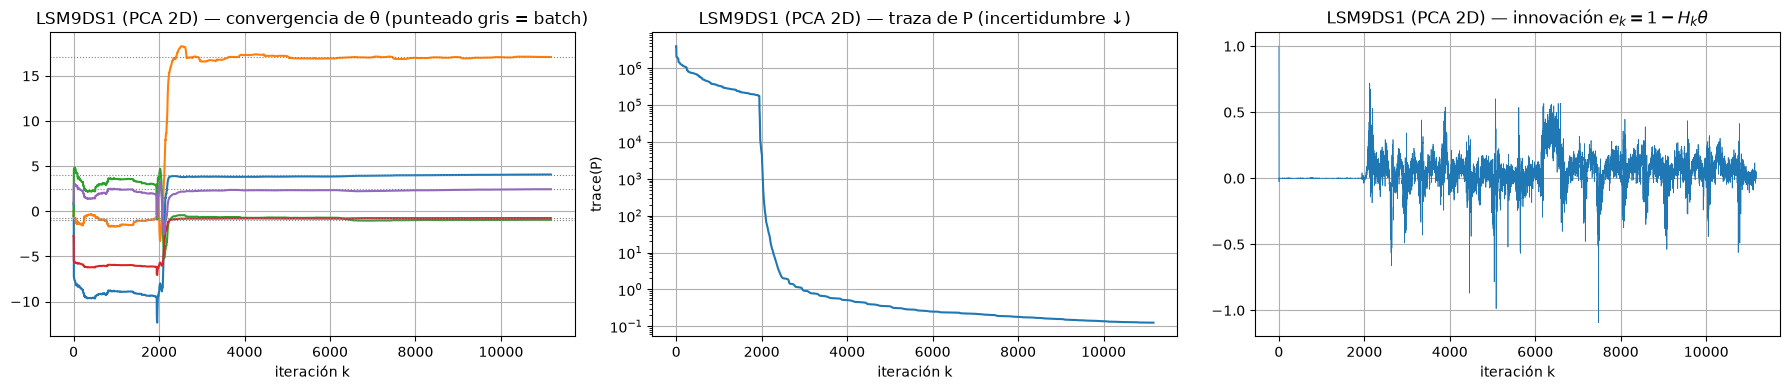

In [21]:
# ====== KF-2D con PCA — LSM9DS1 (df2) : ANÁLISIS DEL ALGORITMO ======
try:
    M3 = df2[['vector.x', 'vector.y', 'vector.z']].to_numpy()
except KeyError:
    M3 = df2[['magnetic_field.x', 'magnetic_field.y', 'magnetic_field.z']].to_numpy()

# --- PCA por SVD: proyección al mejor plano (2 componentes principales) ---
center3 = M3.mean(axis=0)
Xc = M3 - center3
U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
P2 = Xc @ Vt[:2].T                  # coordenadas en el plano (plane.x, plane.y)
x, y = P2[:, 0], P2[:, 1]
N = P2.shape[0]

# Inicialización:  theta_0|0 = 0 (R^5) ,  P_0|0 = p0 I_5
theta = np.zeros(5)
p0 = 1e6
P = p0 * np.eye(5)
Q = np.zeros((5, 5))     # estado estático -> Q = 0 (RLS)
R = 1.0                  # ruido de medición (escalar, y_k = 1)
I5 = np.eye(5)

theta_hist = np.zeros((N, 5))
trace_hist = np.zeros(N)
innov_hist = np.zeros(N)
gain_hist  = np.zeros(N)

for k in range(N):
    # Paso 1 - Predicción (F = I):  theta_k|k-1 = theta_k-1|k-1 ;  P_k|k-1 = P + Q
    P = P + Q

    # Medición k:  H_k (1x5), y_k = 1
    xk, yk = x[k], y[k]
    Hk = np.array([[xk**2, yk**2, 2*xk*yk, xk, yk]])
    y_meas = 1.0

    # Paso 2 - Innovación
    e = y_meas - (Hk @ theta)[0]          # e_k = y_k - H_k theta_k|k-1
    S_k = (Hk @ P @ Hk.T)[0, 0] + R       # S_k = H_k P H_k^T + R

    # Paso 3 - Ganancia de Kalman
    K = (P @ Hk.T) / S_k                  # K_k = P H_k^T S_k^{-1}   (5x1)

    # Paso 4 - Corrección
    theta = theta + K.flatten() * e       # theta_k|k = theta_k|k-1 + K_k e_k
    P = (I5 - K @ Hk) @ P                 # P_k|k = (I - K_k H_k) P_k|k-1

    theta_hist[k] = theta
    trace_hist[k] = np.trace(P)
    innov_hist[k] = e
    gain_hist[k]  = np.linalg.norm(K)

# Solución batch MSE 2D de referencia
H_all = np.column_stack([x**2, y**2, 2*x*y, x, y])
theta_batch = np.linalg.inv(H_all.T @ H_all) @ H_all.T @ np.ones(N)

print("LSM9DS1 (PCA 2D) — análisis del algoritmo")
print("theta_KF    =", np.round(theta, 4))
print("theta_batch =", np.round(theta_batch, 4))
print("||theta_KF - theta_batch|| = %.3e" % np.linalg.norm(theta - theta_batch))
print("trace(P): %.2e (inicial) -> %.2e (final)" % (trace_hist[0], trace_hist[-1]))
print("|innovación| media: todas=%.4f   últimas 100=%.4f"
      % (np.abs(innov_hist).mean(), np.abs(innov_hist[-100:]).mean()))

# Gráficos del algoritmo
fig, ax = plt.subplots(1, 3, figsize=(18, 4))
ax[0].plot(theta_hist)
for j in range(5):
    ax[0].axhline(theta_batch[j], ls=':', lw=0.8, color='gray')
ax[0].set_title("LSM9DS1 (PCA 2D) — convergencia de θ (punteado gris = batch)")
ax[0].set_xlabel("iteración k"); ax[0].grid(True)

ax[1].semilogy(trace_hist)
ax[1].set_title("LSM9DS1 (PCA 2D) — traza de P (incertidumbre ↓)")
ax[1].set_xlabel("iteración k"); ax[1].set_ylabel("trace(P)"); ax[1].grid(True)

ax[2].plot(innov_hist, lw=0.5)
ax[2].set_title("LSM9DS1 (PCA 2D) — innovación $e_k = 1 - H_k\\theta$")
ax[2].set_xlabel("iteración k"); ax[2].grid(True)
plt.tight_layout(); plt.show()

### 3.B — Análisis de los gráficos
Calibración resultante (con $\hat\theta$ del KF 2D): mediciones proyectadas + elipse ajustada y su reconstrucción 3D, nube calibrada (círculo radio 1) y distribución de la norma.

LSM9DS1 (PCA 2D) — resultado de calibración
centro (hard-iron 2D) = [ 0.07740291 -0.06712129]    h = 1.054110432569974
||Pc||: media=0.9905  std=0.0594


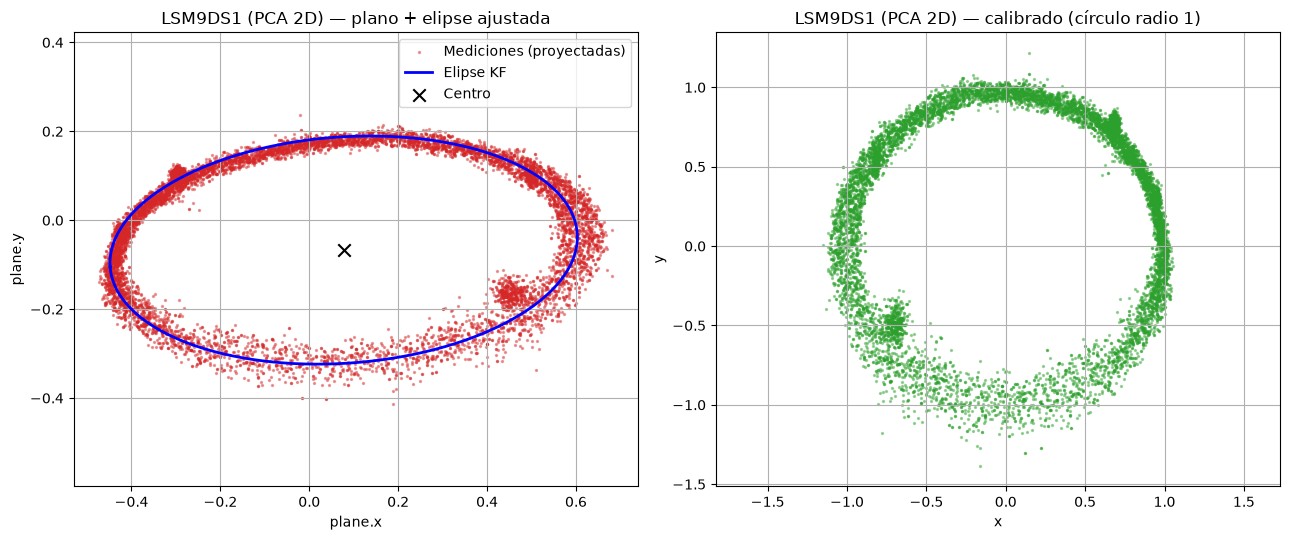

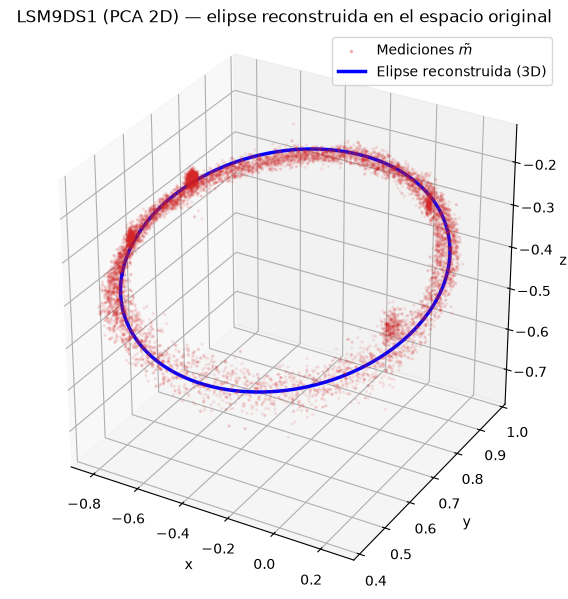

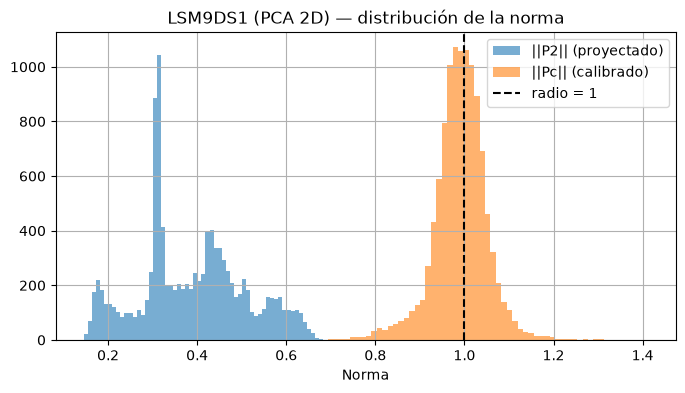

In [22]:
# ====== LSM9DS1 (PCA 2D) : ANÁLISIS DE LOS GRÁFICOS (calibración con θ del KF) ======
a11, a22, a12, n1, n2 = theta                  # theta final del KF (2D)
M2 = np.array([[a11, a12],
               [a12, a22]])
nvec = np.array([n1, n2])
b2 = -0.5 * np.linalg.inv(M2) @ nvec           # centro (hard-iron 2D)
h  = np.sqrt(abs(b2 @ M2 @ b2 + 1.0))          # radio
eigval, Rmat = np.linalg.eigh(M2)              # M2 = R Λ R^T
if np.any(eigval <= 0):
    print("ADVERTENCIA: M2 NO es definida positiva ->", eigval)
S2 = np.diag(np.sqrt(np.abs(eigval))) @ Rmat.T  # Soft-Iron 2D
Pc = (S2 @ (P2 - b2).T).T / h                   # calibrado, radio 1

# Contorno de la elipse ajustada (plano) y su reconstrucción al espacio 3D
t = np.linspace(0, 2*np.pi, 400)
ell2d = b2.reshape(2, 1) + Rmat @ np.diag(h/np.sqrt(np.abs(eigval))) @ np.vstack([np.cos(t), np.sin(t)])
ell3d = center3 + ell2d.T @ Vt[:2]             # (400, 3)

print("LSM9DS1 (PCA 2D) — resultado de calibración")
print("centro (hard-iron 2D) =", b2, "   h =", h)
print("||Pc||: media=%.4f  std=%.4f" %
      (np.linalg.norm(Pc, axis=1).mean(), np.linalg.norm(Pc, axis=1).std()))

# (a) plano + elipse ajustada,  (b) calibrado (círculo radio 1)
fig, ax = plt.subplots(1, 2, figsize=(13, 5.5))
ax[0].scatter(x, y, s=2, alpha=0.4, c='tab:red', label='Mediciones (proyectadas)')
ax[0].plot(ell2d[0], ell2d[1], 'b', lw=2, label='Elipse KF')
ax[0].scatter(b2[0], b2[1], c='k', marker='x', s=80, label='Centro')
ax[0].set_title("LSM9DS1 (PCA 2D) — plano + elipse ajustada")
ax[0].set_xlabel("plane.x"); ax[0].set_ylabel("plane.y")
ax[0].axis('equal'); ax[0].grid(True); ax[0].legend()
ax[1].scatter(Pc[:, 0], Pc[:, 1], s=2, alpha=0.4, c='tab:green')
ax[1].set_title("LSM9DS1 (PCA 2D) — calibrado (círculo radio 1)")
ax[1].set_xlabel("x"); ax[1].set_ylabel("y")
ax[1].axis('equal'); ax[1].grid(True)
plt.tight_layout(); plt.show()

# (c) mediciones crudas 3D + elipse reconstruida en el espacio original
fig = plt.figure(figsize=(8, 6))
ax3 = fig.add_subplot(1, 1, 1, projection='3d')
ax3.scatter(M3[:, 0], M3[:, 1], M3[:, 2], s=2, alpha=0.3, c='tab:red', label='Mediciones $\\tilde{m}$')
ax3.plot(ell3d[:, 0], ell3d[:, 1], ell3d[:, 2], 'b', lw=2.5, label='Elipse reconstruida (3D)')
ax3.set_title("LSM9DS1 (PCA 2D) — elipse reconstruida en el espacio original")
ax3.set_xlabel("x"); ax3.set_ylabel("y"); ax3.set_zlabel("z")
ax3.set_box_aspect([1, 1, 1]); ax3.legend()
plt.tight_layout(); plt.show()

# (d) distribución de la norma
plt.figure(figsize=(8, 4))
plt.hist(np.linalg.norm(P2, axis=1), bins=60, alpha=0.6, label="||P2|| (proyectado)")
plt.hist(np.linalg.norm(Pc, axis=1), bins=60, alpha=0.6, label="||Pc|| (calibrado)")
plt.axvline(1.0, color='k', ls='--', label="radio = 1")
plt.title("LSM9DS1 (PCA 2D) — distribución de la norma")
plt.xlabel("Norma"); plt.legend(); plt.grid(True); plt.show()